**Objetivo:** Este examen tiene como objetivo evaluar la capacidad del estudiante para limpiar, explorar, implementar y evaluar modelos de regresión en un dataset de precios de casas. Utilizaremos el «House Prices Dataset» disponible en Kaggle. Los estudiantes deben demostrar habilidades prácticas en la manipulación de datos, creación de visualizaciones y modelado predictivo.

**Contexto y Descripción del Dataset**

El «House Prices Dataset» contiene datos sobre diversas características de casas residenciales en Ames, Iowa. La tarea es predecir el precio final de cada casa (variable objetivo) en función de sus características.

###1. **Limpieza de Datos:**
* **Identificación y eliminación de valores duplicados:** Asegúrate de que no haya registros duplicados que puedan sesgar los resultados del análisis.
* **Verificación y ajuste de tipos de datos:** Verifica que cada columna tenga el tipo de dato correcto (numérico o categórico) y ajusta si es necesario.
* **Corrección de inconsistencias en valores categóricos:** Revisa las categorías de las variables y unifica aquellos valores que puedan estar escritos de diferentes maneras pero que representen lo mismo.
* **Manejo de valores faltantes adecuadamente:** Identifica y maneja los valores faltantes utilizando técnicas apropiadas como la imputación de la mediana, media o moda, según corresponda.

In [24]:
# Carga de dato de los csv 'train' y 'test'
import pandas as pd
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [27]:
# Identificación y eliminación de valores duplicados
train_df_clean = train_df.drop_duplicates()
test_df_clean = test_df.drop_duplicates()

# Verificación de tipos de datos de 'train'
print(train_df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [29]:
# Verificación de tipos de datos de 'test'
print(test_df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [32]:
# Verificación de valores nulos en 'train'
print("Valores nulos en 'train':")
print(train_df_clean.isnull().sum().sum())

Valores nulos en 'train':
7829


In [33]:
# Verificación de valores nulos en 'test'
print("Valores nulos en 'test':")
print(test_df_clean.isnull().sum().sum())

Valores nulos en 'test':
7878


In [34]:
# Imputación de valores faltantes
numeric_columns = train_df_clean.select_dtypes(include=['float64', 'int64']).columns
categorical_columns = train_df_clean.select_dtypes(include=['object']).columns

# Imputar valores numéricos con la mediana
for col in numeric_columns:
    median = train_df_clean[col].median()
    train_df_clean[col] = train_df_clean[col].fillna(median)
    if col in test_df_clean.columns:
        test_df_clean[col] = test_df_clean[col].fillna(median)

# Imputar valores categóricos con la moda
for col in categorical_columns:
    mode = train_df_clean[col].mode()[0]
    train_df_clean[col] = train_df_clean[col].fillna(mode)
    if col in test_df_clean.columns:
        test_df_clean[col] = test_df_clean[col].fillna(mode)

In [10]:
# Identificar columnas categóricas mal etiquetadas
potential_categorical_columns = ['MSSubClass', 'OverallCond', 'MoSold', 'YrSold']

# Convertirlas a tipo categórico
for col in potential_categorical_columns:
    train_df_clean[col] = train_df_clean[col].astype('category')
    if col in test_df_clean.columns:
        test_df_clean[col] = test_df_clean[col].astype('category')


###2. Exploración de Datos (EDA)
* Visualizaciones univariadas y multivariadas
* Estadísticas Descriptivas

* Visualizaciones univariadas

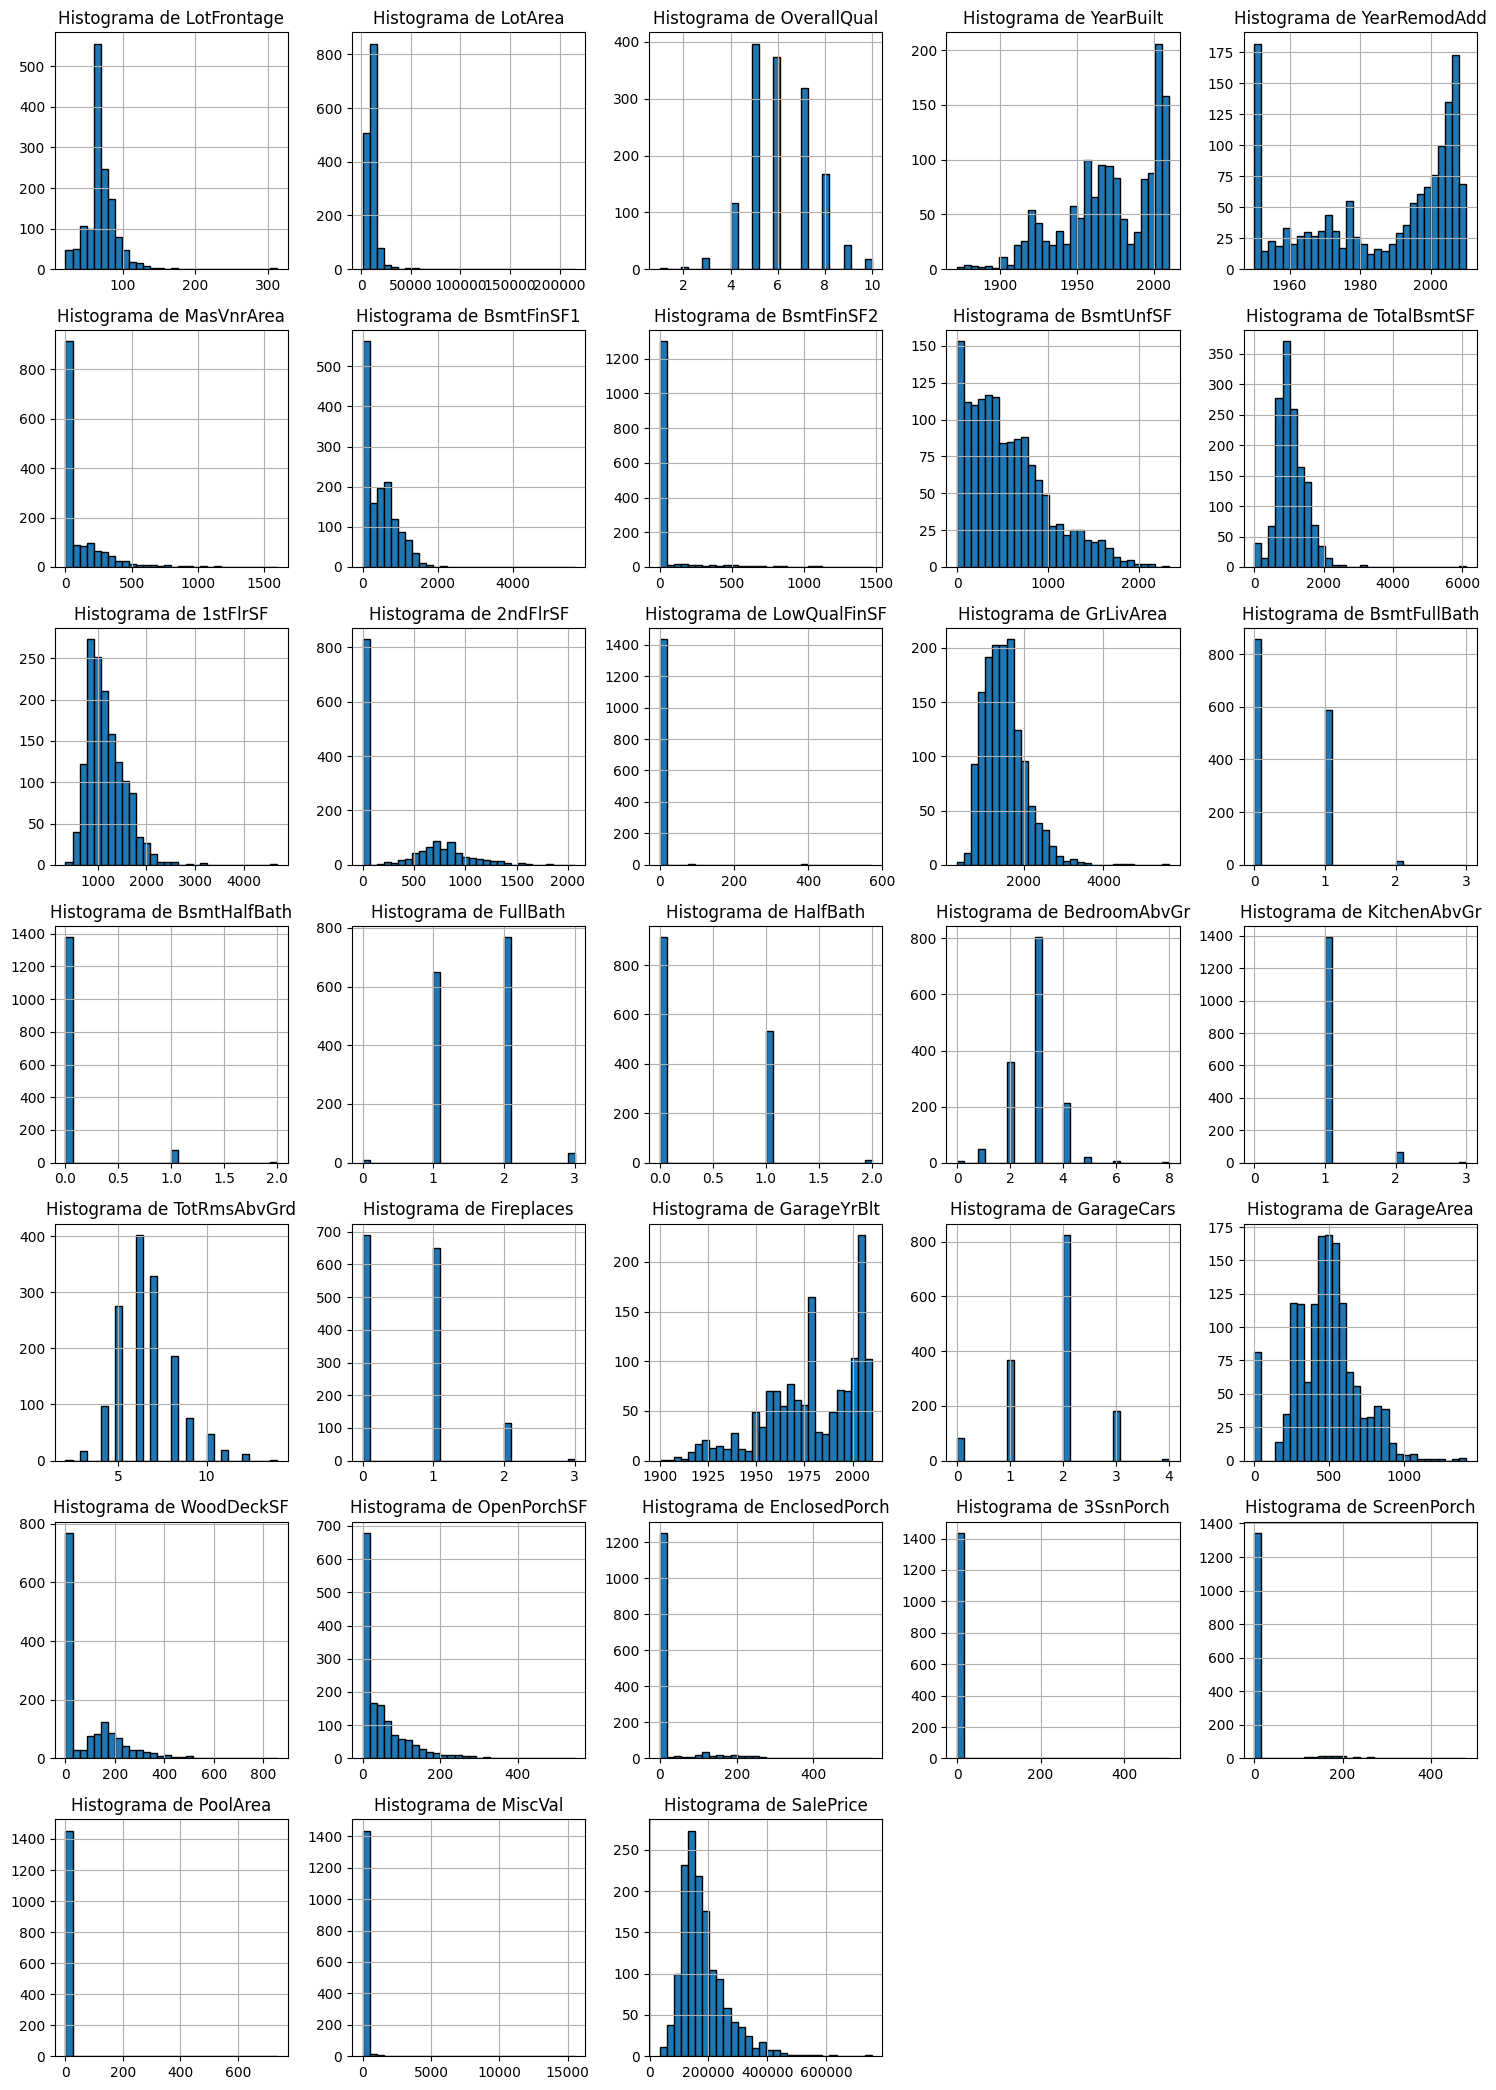

In [14]:
import matplotlib.pyplot as plt

# Filtro de columnas numéricas excluyendo 'Id'
numeric_columns_filtered = [col for col in numeric_columns if col != 'Id']

# Número de histogramas que necesitamos
num_plots = len(numeric_columns_filtered)

# Calcular el número dinámico de filas y columnas
cols = 5  # Número fijo de columnas
rows = (num_plots // cols) + (1 if num_plots % cols != 0 else 0)  # Calculamos las filas necesarias

plt.figure(figsize=(15, rows * 3))  # Ajusto el tamaño según el número de filas
for i, col in enumerate(numeric_columns_filtered, 1):
    plt.subplot(rows, cols, i)  # Crea subplots dinámicamente
    train_df_clean[col].hist(bins=30, edgecolor='black')
    plt.title(f'Histograma de {col}')
    plt.tight_layout()
plt.show()

* Visualización multivariada

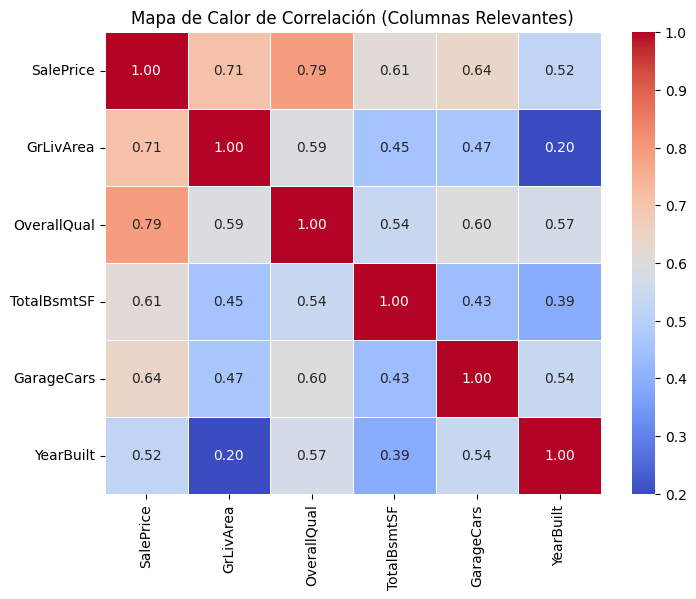

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar las columnas relevantes para la correlación
columns_of_interest = ['SalePrice', 'GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars', 'YearBuilt']
data_of_interest = train_df_clean[columns_of_interest]

# Calcular la matriz de correlación
correlation_matrix = data_of_interest.corr()

# Generar el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Calor de Correlación (Columnas Relevantes)')
plt.show()


* Estadísticas descriptivas

In [40]:
# Estadísticas descriptivas
train_desc_stats = train_df_clean.describe()
train_desc_stats

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,69.863699,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.117123,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,22.027677,9981.264932,1.382997,1.112799,30.202904,20.645407,180.731373,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,60.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,79.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,164.250000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


###3. Implementación de modelos
* Modelos de Regresión: Implementa modelos de Linear Regression y KNN.
* Evaluación de Modelos: Evalúa los modelos utilizando métricas como MSE, RMSE, y R^2.
* Comparación de Rendimiento: Compara los resultados de ambos modelos y discute cuál es el más adecuado para este dataset.

* Preparación de datos de train_df_clean

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# Características seleccionadas y objetivo
features = ['GrLivArea', 'OverallQual', 'YearBuilt', 'TotalBsmtSF', 'GarageCars', 'MSSubClass', 'OverallCond']
target = 'SalePrice'

X = train_df_clean[features]
y = train_df_clean[target]

# División de datos en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocesamiento: OneHotEncoder para variables categóricas
categorical_features = ['MSSubClass', 'OverallCond']
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(drop='first'), categorical_features)],
    remainder='passthrough'
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed = preprocessor.transform(X_val)

* Regresión Lineal

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Modelo de Regresión Lineal
lin_reg = LinearRegression()
lin_reg.fit(X_train_transformed, y_train)

# Predicciones y evaluación
y_pred = lin_reg.predict(X_val_transformed)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

# Resultados de Regresión Lineal
print("Resultados de Regresión Lineal:")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R^2: {r2:.2f}")

Resultados de Regresión Lineal:
MSE: 1471169299.52
RMSE: 38355.82
R^2: 0.81


* KNN

In [22]:
from sklearn.neighbors import KNeighborsRegressor

# Modelo KNN
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_transformed, y_train)

# Predicciones y evaluación
y_pred_knn = knn_reg.predict(X_val_transformed)
mse_knn = mean_squared_error(y_val, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_val, y_pred_knn)

# Resultados de KNN
print("\nResultados de KNN:")
print(f"MSE: {mse_knn:.2f}")
print(f"RMSE: {rmse_knn:.2f}")
print(f"R^2: {r2_knn:.2f}")


Resultados de KNN:
MSE: 2193120876.58
RMSE: 46830.77
R^2: 0.71


###Visualización comparativa

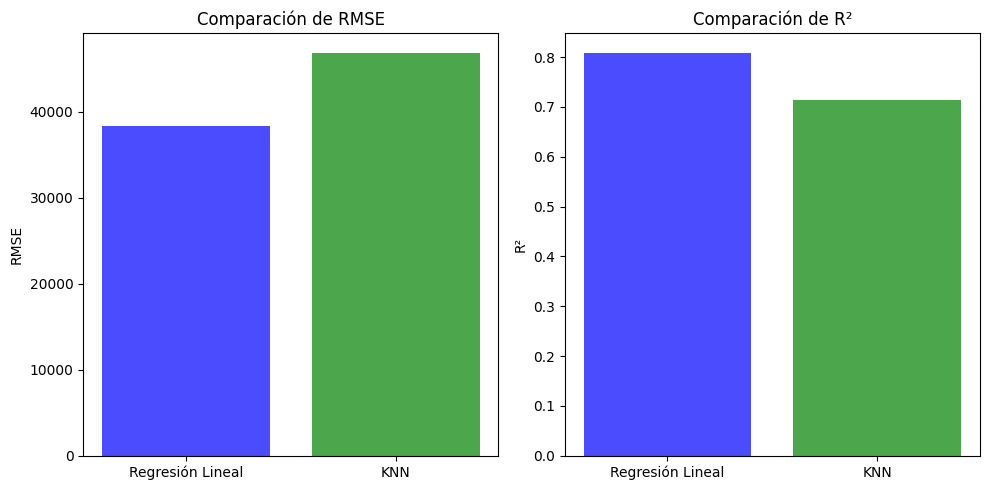

In [23]:
# Comparación de métricas
results = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'KNN'],
    'MSE': [mse, mse_knn],
    'RMSE': [rmse, rmse_knn],
    'R²': [r2, r2_knn]
})

# Visualización de comparación de métricas
plt.figure(figsize=(10, 5))

# Comparación de RMSE
plt.subplot(1, 2, 1)
plt.bar(['Regresión Lineal', 'KNN'], [rmse, rmse_knn], color=['blue', 'green'], alpha=0.7)
plt.title('Comparación de RMSE')
plt.ylabel('RMSE')

# Comparación de R²
plt.subplot(1, 2, 2)
plt.bar(['Regresión Lineal', 'KNN'], [r2, r2_knn], color=['blue', 'green'], alpha=0.7)
plt.title('Comparación de R²')
plt.ylabel('R²')

plt.tight_layout()
plt.show()